# ISL Project - Team-1


# Installing ISLP and importing packages

In [ ]:
pip install ISLP

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 21.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.9/801.9 kB 16.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 4.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pygam to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.2/522.2 kB 27.4 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

from ISLP import confusion_table
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dryBeans_dataset = pd.read_excel('/content/drive/My Drive/Datasets/Dry_Bean_Dataset.xlsx')
dryBeans_dataset.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
5,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600.0,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER
6,30477,670.033,211.050155,184.039050,1.146768,0.489478,30970.0,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER
7,30519,629.727,212.996755,182.737204,1.165591,0.513760,30847.0,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER
8,30685,635.681,213.534145,183.157146,1.165852,0.514081,31044.0,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER
9,30834,631.934,217.227813,180.897469,1.200834,0.553642,31120.0,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER


##Data Description

In [ ]:
# Display the list of features (columns)
features = dryBeans_dataset.columns.tolist()
print("Features (Columns):")
print(features)

# Display the number of samples (rows)
num_samples = len(dryBeans_dataset)
print("\nNumber of Samples (Rows):", num_samples)

print(dryBeans_dataset.info())

Features (Columns):
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Number of Samples (Rows): 13611
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13609 non-null  float64
 4   AspectRation     13608 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13609 non-null  float64
 7   EquivDiameter    13610 non-null  float64
 8   Extent           13608 non-null  float64
 9   Solidity         13608 non-null  float64
 10  roundness        13611 non-null  fl

##Data preprocessing

In [ ]:
# Check for null values
null_values = dryBeans_dataset.isnull().sum()
print("Null Values:\n", null_values)

Null Values:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    2
AspectRation       3
Eccentricity       0
ConvexArea         2
EquivDiameter      1
Extent             3
Solidity           3
roundness          0
Compactness        0
ShapeFactor1       1
ShapeFactor2       1
ShapeFactor3       1
ShapeFactor4       0
Class              0
dtype: int64


In [ ]:
#handling null values
# Custom imputation based on domain knowledge
dryBeans_dataset['MinorAxisLength'].fillna(value=0, inplace=True)
dryBeans_dataset['AspectRation'].fillna(value=0, inplace=True)
dryBeans_dataset['ConvexArea'].fillna(value=0, inplace=True)
dryBeans_dataset['EquivDiameter'].fillna(value=0, inplace=True)
dryBeans_dataset['Extent'].fillna(value=0, inplace=True)
dryBeans_dataset['Solidity'].fillna(value=0, inplace=True)
dryBeans_dataset['ShapeFactor1'].fillna(value=0, inplace=True)
dryBeans_dataset['ShapeFactor2'].fillna(value=0, inplace=True)
dryBeans_dataset['ShapeFactor3'].fillna(value=0, inplace=True)

##Exploratory data analysis

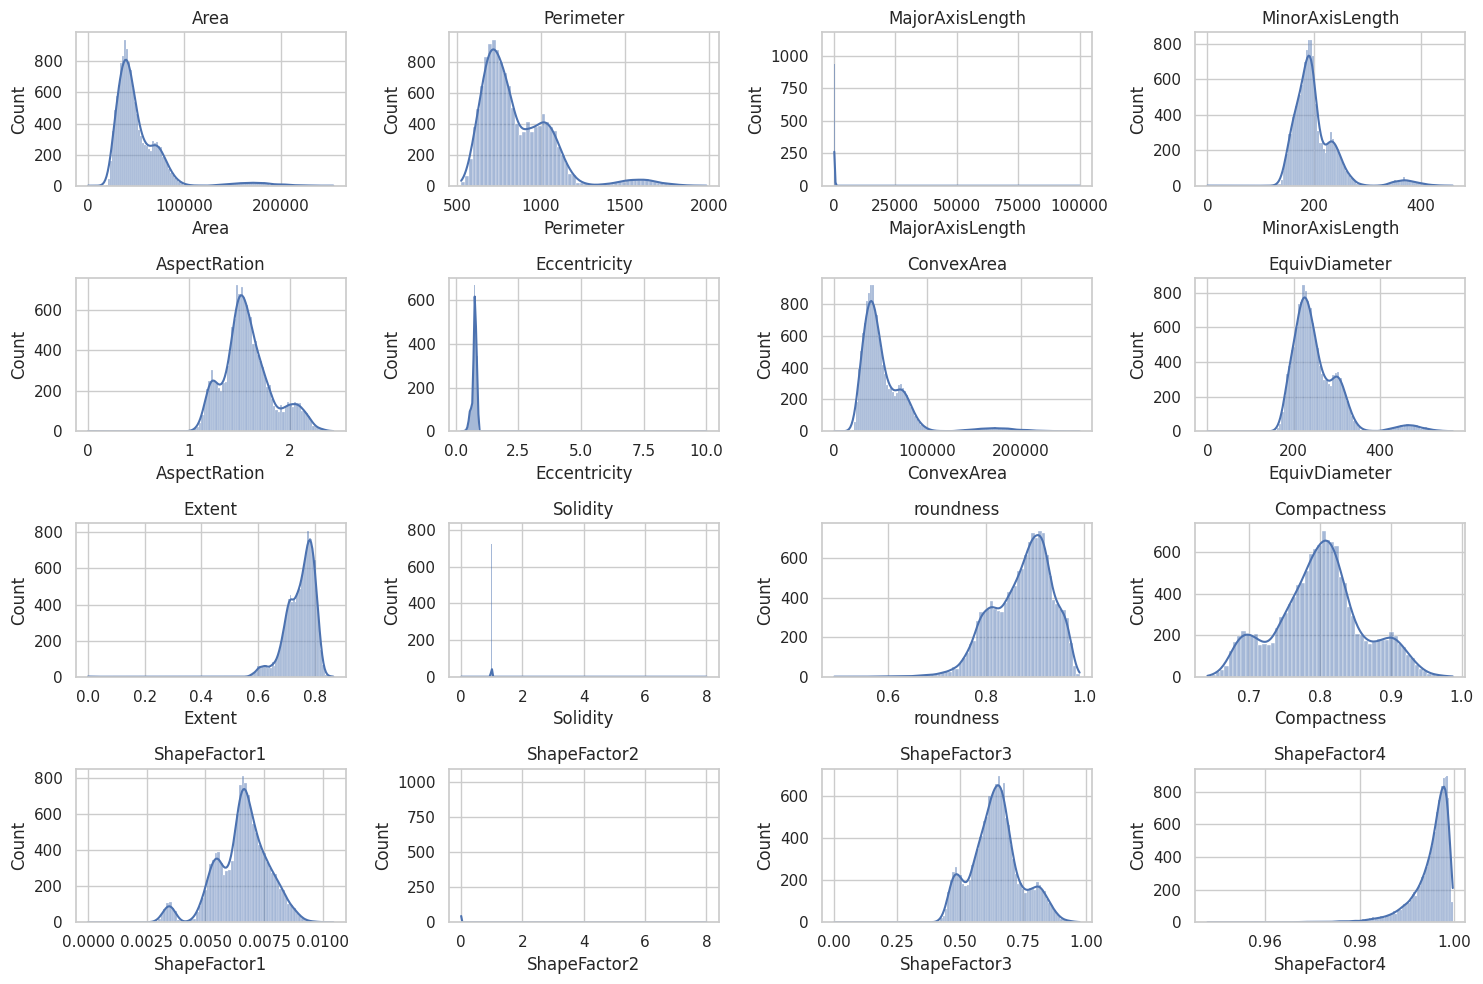

<ipython-input-9-d6fbc3c63645>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=dryBeans_dataset, palette='Set2')


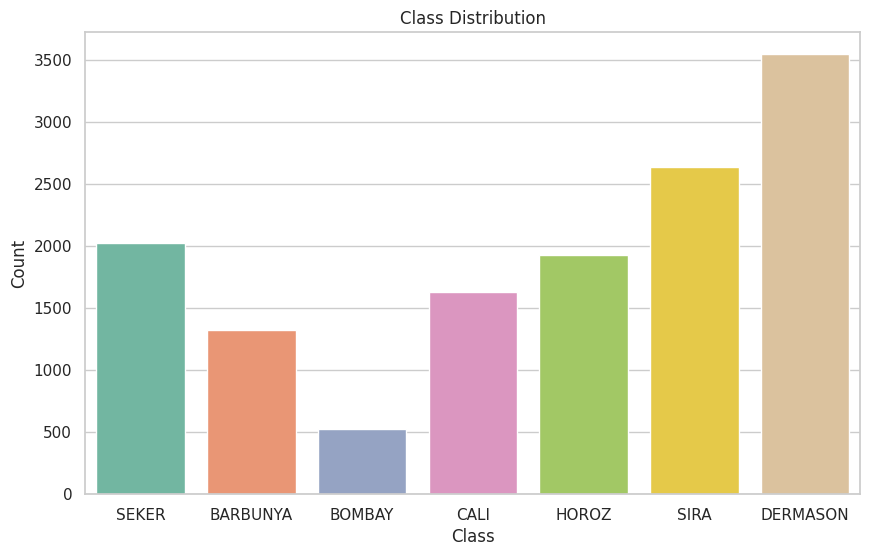

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for Seaborn plots
sns.set(style="whitegrid")

# Define the numerical features (excluding the 'Class' column)
numerical_features = dryBeans_dataset.drop(columns=['Class']).columns

# Histograms of numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, start=1):
    plt.subplot(4, 4, i)
    sns.histplot(dryBeans_dataset[feature], kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

# # Box plots of numerical features grouped by class
# plt.figure(figsize=(15, 10))
# for i, feature in enumerate(numerical_features, start=1):
#     plt.subplot(4, 4, i)
#     sns.boxplot(x='Class', y=feature, data=dryBeans_dataset)
#     plt.title(feature)
# plt.tight_layout()
# plt.show()

# # Pair plot of numerical features
# sns.pairplot(dryBeans_dataset[numerical_features])
# plt.show()

# Bar plot of class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=dryBeans_dataset, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

##Model Development

#Supervised methods (LDA, Decision Trees)

LDA by Vinay

In [ ]:
# Separate features (X) and target variable (y)
X = dryBeans_dataset.drop(columns=['Class'])
y = dryBeans_dataset['Class']

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the training set
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing set
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Initialize and fit LDA model
lda = LDA(store_covariance=True)
lda.fit(X_train_scaled, y_train)

# Make predictions on the testing set
lda_predictions = lda.predict(X_test_scaled)

# Create labels based on the predictions
labels = lda_predictions

In [ ]:
from scipy.stats import norm

# Get the coefficients and intercept from the LDA model
coefficients = lda.coef_
intercept = lda.intercept_

# Calculate the p-values for each predictor
p_values = 2 * norm.cdf(-abs(coefficients), loc=0, scale=1)

# Print the p-values for each predictor
print("P-values for each predictor:")
for i, feature in enumerate(X.columns):
    print(f"{feature}: {p_values[0, i]}")


P-values for each predictor:
Area: 3.906303387783422e-216
Perimeter: 2.0711556107597045e-126
MajorAxisLength: 0.9717252955786121
MinorAxisLength: 0.23583554736716406
AspectRation: 0.13090084792783413
Eccentricity: 0.8960276870159132
ConvexArea: 4.8837636231227177e-08
EquivDiameter: 8.880995204829977e-241
Extent: 0.7260306388087068
Solidity: 0.994026232892248
roundness: 0.0005392263708830548
Compactness: 0.0
ShapeFactor1: 3.3265189610759263e-28
ShapeFactor2: 0.9935562603684228
ShapeFactor3: 0.0
ShapeFactor4: 0.16782017274924532


In [ ]:
## Evaluate predictions
# from sklearn.metrics import confusion_matrix, classification_report
# from mlxtend.plotting import plot_confusion_matrix

# confusion = confusion_matrix(y_test, lda_predictions)
# classification_rep = classification_report(y_test, lda_predictions)

# print("Confusion Matrix:")
# print(confusion)
# print("\nClassification Report:")
# print(classification_rep)

# # Plot confusion matrix
# plt.figure(figsize=(8, 6))
# plot_confusion_matrix(lda, X_test_scaled, y_test, cmap=plt.cm.Blues)
# plt.title('Confusion Matrix')
# plt.show()

In [ ]:
# Evaluate predictions
from sklearn.metrics import confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix

# Get predictions from the LDA model
lda_predictions = lda.predict(X_test_scaled)

# Calculate confusion matrix and classification report
confusion = confusion_matrix(y_test, lda_predictions)
classification_rep = classification_report(y_test, lda_predictions)

print("Confusion Matrix:")
print(confusion)
print("\nClassification Report:")
print(classification_rep)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plot_confusion_matrix(confusion, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


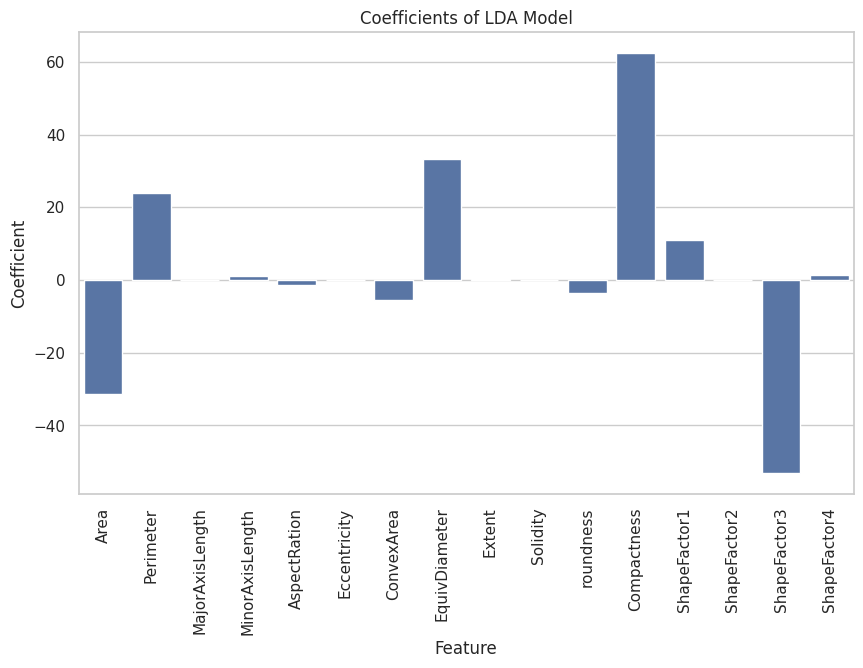

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=lda.coef_[0])
plt.xticks(rotation=90)
plt.title('Coefficients of LDA Model')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.show()


Decision Trees by Tejeswar

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
import requests as rq
import urllib.request
import zipfile

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip'
filename = 'DryBeanDataset.zip'

# Download the zip file
urllib.request.urlretrieve(url, filename)

# Extract the contents of the zip file
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall('.')

# Load the dataset
drybean = pd.read_excel("./DryBeanDataset/Dry_Bean_Dataset.xlsx")

""" (FROM SOURCE)
Summary Statistics:
          Min         Max       Mean                SD                   Class Correlation
area:      20420       254616    53048               1978.674050974541    1.000000
perimeter: 610.291     1985.370  855.283458599662    214.28969589196143   0.966722
compact:   0.640577    0.987303  0.7998636818716444  0.06171346312041559  -0.357530
roundness: 0.489618    0.990685  0.8732818313104205  0.05951988794823966  -0.268067
"""

!pip install tensorflow
!pip install lazypredict

##Data preprocessing

In [ ]:
# Calculate the count of each target variable
count = drybean['Class'].value_counts()
print(count)

DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: Class, dtype: int64


##Data Description

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Split the dataset into training and testing sets
X = drybean.drop('Class', axis=1)
y = drybean['Class']

print("Before OverSampling, counts of 'DERMASON': {}".format(sum(y == 'DERMASON')))
print("Before OverSampling, counts of 'SIRA': {}".format(sum(y == 'SIRA')))
print("Before OverSampling, counts of 'SEKER': {}".format(sum(y == 'SEKER')))
print("Before OverSampling, counts of 'HOROZ': {}".format(sum(y == 'HOROZ')))
print("Before OverSampling, counts of 'CALI': {}".format(sum(y == 'CALI')))
print("Before OverSampling, counts of 'BARBUNYA': {}".format(sum(y == 'BARBUNYA')))
print("Before OverSampling, counts of 'BOMBAY': {}\n".format(sum(y == 'BOMBAY')))

# import SMOTE module from imblearn library
# pip install imblearn (if you don't have imblearn in your system)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 2)
X_res, y_res = sm.fit_resample(X, y.ravel())

print('After OverSampling, the shape of train_X: {}'.format(X_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_res.shape))

print("After OverSampling, counts of 'DERMASON': {}".format(sum(y_res == 'DERMASON')))
print("After OverSampling, counts of 'SIRA': {}".format(sum(y_res == 'SIRA')))
print("After OverSampling, counts of 'SEKER': {}".format(sum(y_res == 'SEKER')))
print("After OverSampling, counts of 'HOROZ': {}".format(sum(y_res == 'HOROZ')))
print("After OverSampling, counts of 'CALI': {}".format(sum(y_res == 'CALI')))
print("After OverSampling, counts of 'BARBUNYA': {}".format(sum(y_res == 'BARBUNYA')))
print("After OverSampling, counts of 'BOMBAY': {}\n".format(sum(y_res == 'BOMBAY')))

Before OverSampling, counts of 'DERMASON': 3546
Before OverSampling, counts of 'SIRA': 2636
Before OverSampling, counts of 'SEKER': 2027
Before OverSampling, counts of 'HOROZ': 1928
Before OverSampling, counts of 'CALI': 1630
Before OverSampling, counts of 'BARBUNYA': 1322
Before OverSampling, counts of 'BOMBAY': 522

After OverSampling, the shape of train_X: (24822, 16)
After OverSampling, the shape of train_y: (24822,) 

After OverSampling, counts of 'DERMASON': 3546
After OverSampling, counts of 'SIRA': 3546
After OverSampling, counts of 'SEKER': 3546
After OverSampling, counts of 'HOROZ': 3546
After OverSampling, counts of 'CALI': 3546
After OverSampling, counts of 'BARBUNYA': 3546
After OverSampling, counts of 'BOMBAY': 3546



##Exploratory data analysis

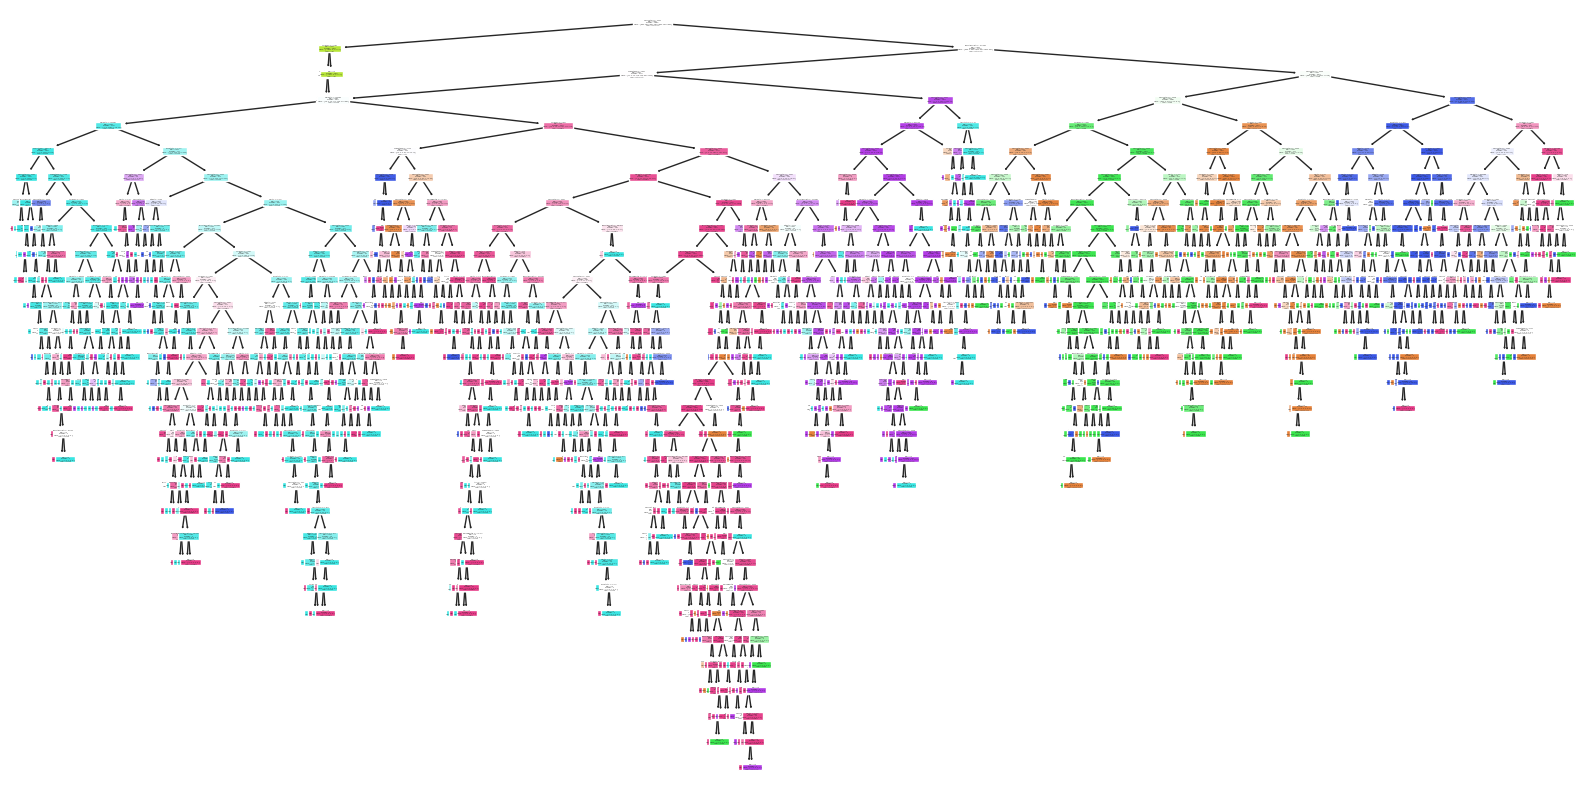

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Split the resampled dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train the decision tree classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Plot the decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['DERMASON', 'SIRA', 'SEKER', 'HOROZ', 'CALI', 'BARBUNYA', 'BOMBAY'])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Split the dataset into training and testing sets
X = drybean.drop('Class', axis=1)
y = drybean['Class']

# Normalize numerical values into ranges
scaler = MinMaxScaler()

# Select the columns you want to scale
columns_to_scale =  drybean.columns[:-1]

# Fit the scaler on the selected columns
scaler.fit(drybean[columns_to_scale])

# Transform the selected columns using the scaler
drybean[columns_to_scale] = scaler.transform(drybean[columns_to_scale])

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size = 0.2, random_state = 42)

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

 97%|█████████▋| 28/29 [02:55<00:01,  1.67s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005920 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 19857, number of used features: 16
[LightGBM] [Info] Start training from score -1.948633
[LightGBM] [Info] Start training from score -1.947573
[LightGBM] [Info] Start training from score -1.949341
[LightGBM] [Info] Start training from score -1.950048
[LightGBM] [Info] Start training from score -1.942994
[LightGBM] [Info] Start training from score -1.939485
[LightGBM] [Info] Start training from score -1.943345
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


100%|██████████| 29/29 [02:58<00:00,  6.15s/it]

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.95               0.95    None      0.95   
LabelPropagation                   0.95               0.95    None      0.95   
RandomForestClassifier             0.95               0.95    None      0.95   
ExtraTreesClassifier               0.95               0.95    None      0.95   
LabelSpreading                     0.95               0.95    None      0.95   
BaggingClassifier                  0.95               0.95    None      0.95   
SVC                                0.95               0.95    None      0.95   
KNeighborsClassifier               0.95               0.95    None      0.95   
LogisticRegression                 0.94               0.94    None      0.94   
LinearSVC                          0.94               0.94    None      0.94   
CalibratedClassifierCV             0.94 

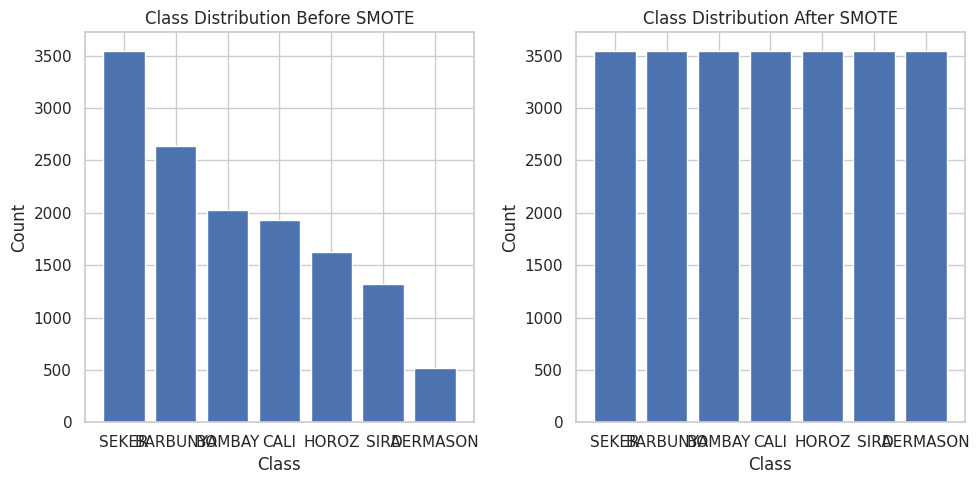

In [ ]:
import matplotlib.pyplot as plt

# Plot class distribution before SMOTE
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(y.unique(), y.value_counts())
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

# Plot class distribution after SMOTE
plt.subplot(1, 2, 2)
plt.bar(pd.Series(y_res).unique(), pd.Series(y_res).value_counts())
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

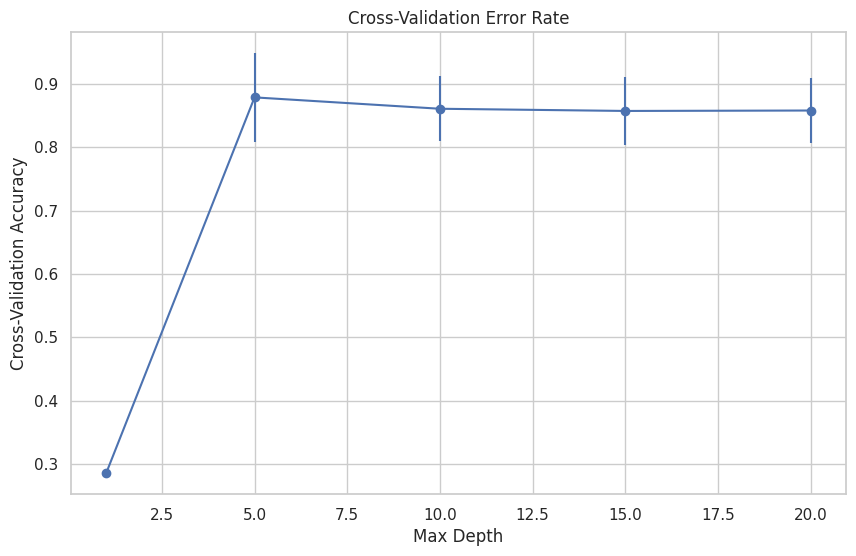

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Define a range of values for hyperparameters (e.g., max_depth)
param_range = [1, 5, 10, 15, 20]

# Initialize lists to store mean cross-validation scores and standard deviations
mean_scores = []
std_scores = []

# Iterate over each hyperparameter value
for param in param_range:
    # Initialize and train the decision tree classifier with the current hyperparameters
    clf = DecisionTreeClassifier(max_depth=param)

    # Perform cross-validation and compute scores
    scores = cross_val_score(clf, X_res, y_res, cv=5)

    # Compute mean and standard deviation of scores
    mean_score = np.mean(scores)
    std_score = np.std(scores)

    # Append mean score and standard deviation to lists
    mean_scores.append(mean_score)
    std_scores.append(std_score)

# Plot the cross-validation error rate graph
plt.figure(figsize=(10, 6))
plt.errorbar(param_range, mean_scores, yerr=std_scores, fmt='-o', color='b')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Cross-Validation Error Rate')
plt.grid(True)
plt.show()


In [ ]:

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Split the dataset into training and testing sets
x_data = drybean.drop('Class', axis=1)
y = drybean['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x_data, y, test_size=0.2, random_state=42)

# Train a Decision Tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the accuracy of the Decision Tree model
accuracy = accuracy_score(y_test, y_pred)
formatted_accuracy = format(accuracy, '.0%')
print("Accuracy (without cross-validation):", formatted_accuracy)

X_merged_df = X_train.append(X_test)
y_merged_df = y_train.append(y_test)

# Perform cross-validation
cv_scores = cross_val_score(dt_model, X_merged_df, y_merged_df, cv=5)  # Use 5-fold cross-validation
average_accuracy = cv_scores.mean()
formatted_cv_accuracy = format(average_accuracy, '.0%')
print("Cross-validated Accuracy:", formatted_cv_accuracy)

Accuracy (without cross-validation): 89%
Cross-validated Accuracy: 89%


In [ ]:
# Evaluate the predictions
correct = 0

items = len(X_test)

for i in range(items):
    true_class = y_test.iloc[i]
    predicted_class = y_pred[i]

    try:
        if true_class == predicted_class:
            print(true_class, predicted_class, "XXXXXXXXXX ACCURATE")
            correct += 1
        else:
            print(true_class, predicted_class, "XXXXXXXXXX item#", i+1, "INACCURATE")
    except:
        print("Can't Determine Item #", i+1, "attributes:", ",".join(str(attr) for attr in X_test.iloc[i]))

print("\n",correct/len(y_pred))

#Unsupervised methods (K-Means, Hierarchical Clustering)

K-means by Sindhu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

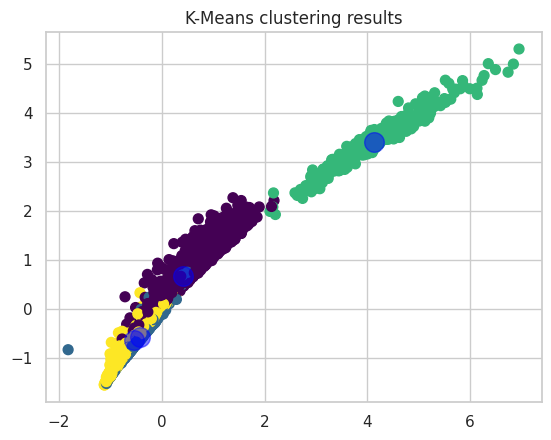

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715.00,190.14,0.76,0.99,0.96,0.91,0.01,0.00,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172.00,191.27,0.78,0.98,0.89,0.95,0.01,0.00,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690.00,193.41,0.78,0.99,0.95,0.91,0.01,0.00,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724.00,195.47,0.78,0.98,0.90,0.93,0.01,0.00,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417.00,195.90,0.77,0.99,0.98,0.97,0.01,0.00,0.94,1.00,SEKER
5,30279,634.93,212.56,181.51,1.17,0.52,30600.00,196.35,0.78,0.99,0.94,0.92,0.01,0.00,0.85,1.00,SEKER
6,30477,670.03,211.05,184.04,1.15,0.49,30970.00,196.99,0.76,0.98,0.85,0.93,0.01,0.00,0.87,1.00,SEKER
7,30519,629.73,213.00,182.74,1.17,0.51,30847.00,197.12,0.77,0.99,0.97,0.93,0.01,0.00,0.86,1.00,SEKER
8,30685,635.68,213.53,183.16,1.17,0.51,31044.00,197.66,0.77,0.99,0.95,0.93,0.01,0.00,0.86,1.00,SEKER
9,30834,631.93,217.23,180.90,1.20,0.55,31120.00,198.14,0.78,0.99,0.97,0.91,0.01,0.00,0.83,1.00,SEKER


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=48)
kmeans.fit(X_train_scaled)

# Get cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Visualize clustering results (select two dimensions)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='Blue', s=200, alpha=0.5)
plt.title("K-Means clustering results")
plt.show()

# Displaying the dataset with cluster labels
dryBeans_dataset.head(10)

In [ ]:
# Calculate silhouette scores for different number of clusters
for n_clusters in range(2, 6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=48)
    cluster_labels = kmeans.fit_predict(X_train_scaled)
    silhouette_avg = silhouette_score(X_train_scaled, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

For n_clusters = 2 The average silhouette_score is : 0.3897576228885212
For n_clusters = 3 The average silhouette_score is : 0.3984238079435358
For n_clusters = 4 The average silhouette_score is : 0.34826897182616856
For n_clusters = 5 The average silhouette_score is : 0.3763220690062463


Hierarchical Clustering by Praneeth

In [ ]:
import pandas as pd
from numpy import asarray
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from ISLP.cluster import compute_linkage

In [ ]:
from sklearn.cluster import(KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (dendrogram,cut_tree)

In [ ]:
dryBeans_dataset.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715.00,190.14,0.76,0.99,0.96,0.91,0.01,0.00,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172.00,191.27,0.78,0.98,0.89,0.95,0.01,0.00,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690.00,193.41,0.78,0.99,0.95,0.91,0.01,0.00,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724.00,195.47,0.78,0.98,0.90,0.93,0.01,0.00,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417.00,195.90,0.77,0.99,0.98,0.97,0.01,0.00,0.94,1.00,SEKER
5,30279,634.93,212.56,181.51,1.17,0.52,30600.00,196.35,0.78,0.99,0.94,0.92,0.01,0.00,0.85,1.00,SEKER
6,30477,670.03,211.05,184.04,1.15,0.49,30970.00,196.99,0.76,0.98,0.85,0.93,0.01,0.00,0.87,1.00,SEKER
7,30519,629.73,213.00,182.74,1.17,0.51,30847.00,197.12,0.77,0.99,0.97,0.93,0.01,0.00,0.86,1.00,SEKER
8,30685,635.68,213.53,183.16,1.17,0.51,31044.00,197.66,0.77,0.99,0.95,0.93,0.01,0.00,0.86,1.00,SEKER
9,30834,631.93,217.23,180.90,1.20,0.55,31120.00,198.14,0.78,0.99,0.97,0.91,0.01,0.00,0.83,1.00,SEKER


#Data Description

In [ ]:
# Display the list of features (columns)
features = dryBeans_dataset.columns.tolist()
print("Features (Columns):")
print(features)

# Display the number of samples (rows)
num_samples = len(dryBeans_dataset)
print("\nNumber of Samples (Rows):", num_samples)

print(dryBeans_dataset.info())

Features (Columns):
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Number of Samples (Rows): 13611
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  fl

#Data Preprocesing

In [ ]:
# Check for null values
null_values = dryBeans_dataset.isnull().sum()
print("Null Values:\n", null_values)

Null Values:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [ ]:
dryBeans_dataset = dryBeans_dataset.dropna(axis=0) #handling null values

#Model Development

In [ ]:
# Separate features (X) and target variable (y)
X = dryBeans_dataset.drop(columns=['Class'])
y = dryBeans_dataset['Class']

In [44]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
method = 'agglom-complete'

ag = AgglomerativeClustering(n_clusters=7, linkage='complete', compute_full_tree=True)
ag.fit(X)

dryBeans_dataset[method] = ag.labels_

c_linkage = linkage(ag.children_, method='complete')  # Compute the linkage using the complete method
fig, ax = plt.subplots(1, 1, figsize=(8, 8))  # Show the dendrogram
dendrogram(c_linkage, ax=ax)
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7b34fb5f56c0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7b34fb5f4940> (for post_execute):


KeyboardInterrupt: 

#Performance Evaluation

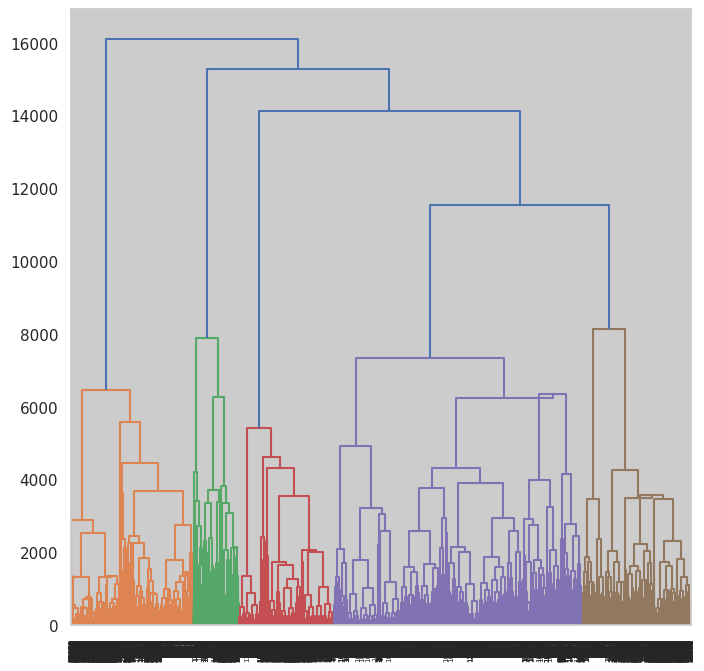

In [46]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
method = 'agglom-single'

ag = AgglomerativeClustering(n_clusters=7, linkage='single', compute_full_tree=True)
ag.fit(X)

dryBeans_dataset[method] = ag.labels_

c_linkage = linkage(ag.children_, method='centroid')  # Compute the linkage using the complete method
fig, ax = plt.subplots(1, 1, figsize=(8, 8))  # Show the dendrogram
dendrogram(c_linkage, ax=ax)
plt.show()

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split the dataset into features (X) and target variable (y)
X = dryBeans_dataset.drop(columns=['Class'])
y = dryBeans_dataset['Class']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Initialize and train LDA classifier
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(X_train, y_train)

# Predictions
dt_predictions = dt_classifier.predict(X_test)
lda_predictions = lda_classifier.predict(X_test)

# Performance Metrics
dt_accuracy = accuracy_score(y_test, dt_predictions)
lda_accuracy = accuracy_score(y_test, lda_predictions)

dt_precision = precision_score(y_test, dt_predictions, average='weighted')
lda_precision = precision_score(y_test, lda_predictions, average='weighted')

dt_recall = recall_score(y_test, dt_predictions, average='weighted')
lda_recall = recall_score(y_test, lda_predictions, average='weighted')

dt_f1 = f1_score(y_test, dt_predictions, average='weighted')
lda_f1 = f1_score(y_test, lda_predictions, average='weighted')

dt_roc_auc = roc_auc_score(y_test, dt_predictions, average='weighted', multi_class='ovo')
lda_roc_auc = roc_auc_score(y_test, lda_predictions, average='weighted', multi_class='ovo')

# Print Performance Metrics
print("Decision Tree Classifier:")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)
print("ROC AUC Score:", dt_roc_auc)

print("\nLinear Discriminant Analysis Classifier:")
print("Accuracy:", lda_accuracy)
print("Precision:", lda_precision)
print("Recall:", lda_recall)
print("F1 Score:", lda_f1)
print("ROC AUC Score:", lda_roc_auc)

ValueError: could not convert string to float: 'SEKER'